In [255]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

In [256]:
house_prices_df  = pd.read_csv("prix_maisons.csv")
house_prices_df .head(5)

,Unnamed: 0,surface,prix
0,0,63.905080,121984.411424
1,1,77.215149,158934.431054
2,2,68.221070,138770.452370
3,3,63.590655,119500.090848
4,4,53.892384,115226.028863


In [257]:
house_prices_df .info()
random.seed(1)

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   surface     100 non-null    float64
 2   prix        100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [258]:
x_mean, x_std = house_prices_df["surface"].mean(), house_prices_df["surface"].std()
y_mean, y_std = house_prices_df["prix"].mean(), house_prices_df["prix"].std()

house_prices_df["surface"] = (house_prices_df["surface"] - x_mean )/ x_std
house_prices_df["prix"] = (house_prices_df["prix"] - y_mean )/ y_std
x_mean , y_std , y_mean , y_std

(np.float64(57.8235071610014),
 np.float64(46539.31094966548),
 np.float64(116608.68604238844),
 np.float64(46539.31094966548))

1.1.La standardisation permet de normer et centrer nos valeurs, réduit les distances et donc le temps de calcul, notammant pour la mse et rmse. On reduit ainsi aussi les mouvements de valeurs de a et b avant convergence vers le minimum <br>
Les distance étant grandes, l'ajustement pas par aps demande un nombre de calculs beaucoup plus grand. des biais peuvent apparaitre si on n'est pas sur la même échelle.

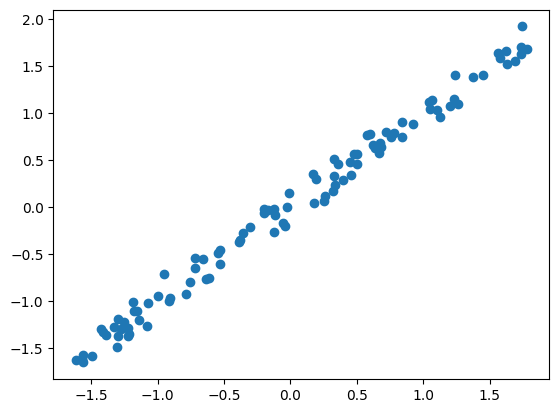

In [259]:
plt.scatter(house_prices_df["surface"], house_prices_df["prix"])

1.2 la relation semble linéaire à la vu humaine et standardisée. une courbe quadratique peut permettre un leger ajustement qui en denormalisant les résultats donnerai de meileurs performances.

In [260]:
def linear_regression(a, b, problems):
	return a * problems + b

def plot(problems, solutions, predictions , epoch , learning_rate):
	plt.figure(figsize=(15, 6))
	plt.plot(problems, solutions, "ro")
	plt.plot(problems, predictions, "g")
	plt.title(f"entrainement avec {epoch} epochs et learning rate à {learning_rate}")
	plt.show()



def plot_rmse(rmse_values_per_epoch):
	plt.figure(figsize=(15, 6))
	plt.plot(rmse_values_per_epoch, "b")
	plt.xlabel("epochs")
	plt.ylabel("rmse")
	plt.show()
	
    
def backpropagation(a, b, n, problems, solutions, learning_rate, visual=False):
	dmse_da = 2/n * sum((a * problems + b - solutions) * problems)
	dmse_db = 2/n * sum(a * problems + b - solutions)

	a -= learning_rate * dmse_da
	b -= learning_rate * dmse_db
	
	predictions = linear_regression(a, b, problems)
	rmse = compute_rmse(predictions, solutions)


	if visual :
		plot(problems=problems, solutions=solutions, predictions=predictions)

	return a, b, rmse


def gradient_descent(problems, solutions, learning_rate=10**(-3), epochs=100, a=None, b=None):
	a, b = random.random(), random.random()

	n = len(problems)
	
	rmse_values_per_epoch = []

	for index_epoch in range(epochs):

		a, b, rmse = backpropagation(a, b, n, problems, solutions, learning_rate)
		rmse_values_per_epoch.append(rmse)


	predictions = linear_regression(a, b, problems)
	plot(problems=problems, solutions=solutions, predictions=predictions, epoch=epochs , learning_rate=learning_rate)

	return a, b, rmse_values_per_epoch


def compute_rmse(predictions, solutions):
	n = len(predictions)
	return  np.sqrt(np.mean((predictions - solutions)**2))

2.1 le modèle a trois poids, a,b,c <br>
ce modèle est plus maléable qu'un momdèle affine car il permet de rpendre en compte des petits écart et s'y adapter sans être par defaut bloqué par une forme linéaire. il eput sembler se rapprocher plus au mieux de l'ensemble de nos points, surtout dans un modèle qui peut ne aps être linéaire à 100%<br>
2.2 La MSE nous permet de visualiser l'erreur moyenne au carré, pénalisant les grands écart à cause du carré.<br>
La RMSE est la racine carrée de la MSE, mettant plus  à plat les résultats et pénalisant moins les grands écarts. La RMSE peut être une metric plus lisible que la MSE dans un cas ou nous avons une base de données avec de grands écarts difficilement optimisable, car l'échelle d'erreur sera plus petite, plus simple à analyser, et plus siple pour le modele comme base de calcul de l'erreur.<br><br>
3.1 df/d^y = 2(^y-y)*^y'<br>
3.2 d^y/da = 2(ax^2+bx+c)*x^2<br>
d^y/db = 2(ax^2+bx+c)*x<br>
d^y/dc = 2(ax^2+bx+c)<br>
3.3 1/n est la moyenne de la somme de nos résultats. par factorisation, 1/n....2(....) = 2/n....<br>
4.1 Le learning_rate nous permet de faire un pas infiniment petit entre deux itération ( localement), afin de pouvoir converger dans le sens inverse du gradient vers notre minimum.<br>
4.2 Un learning_rate trop grand pourrait créer des rebonds lorsqu'on se rapproche du minimumm, et avoir une courbe d'erreur en dent de scie, ou bien reussir a converger mais avec une qualité mauvaise.<br>
4.3 un learning_rate trop petit pourrait generer un entrainement infiniment long.



5.1 la RMSE est sencée être strictement décroissante àà chaque epochs sauf si le learning_rate est trop grand ce qui créé un rebond. Mais si il n'y a pas de probleme de elearning_rate, alors oui la RMSE est sencée être strictement décroissante jusqu'au minimum puis être nulle.<br>
5.2 Nous pouvons stopper l'entrainement d'un modele avant la fin de son nombre d'ittération d'epochs si l'entraineemnt remplie une conditions. Par exemple avoir une amélioratio du modèle de moins de 0.001% d'un epoch  à l'autre.<br>



Il s'agit du modèle entrainé sur 100 epochs


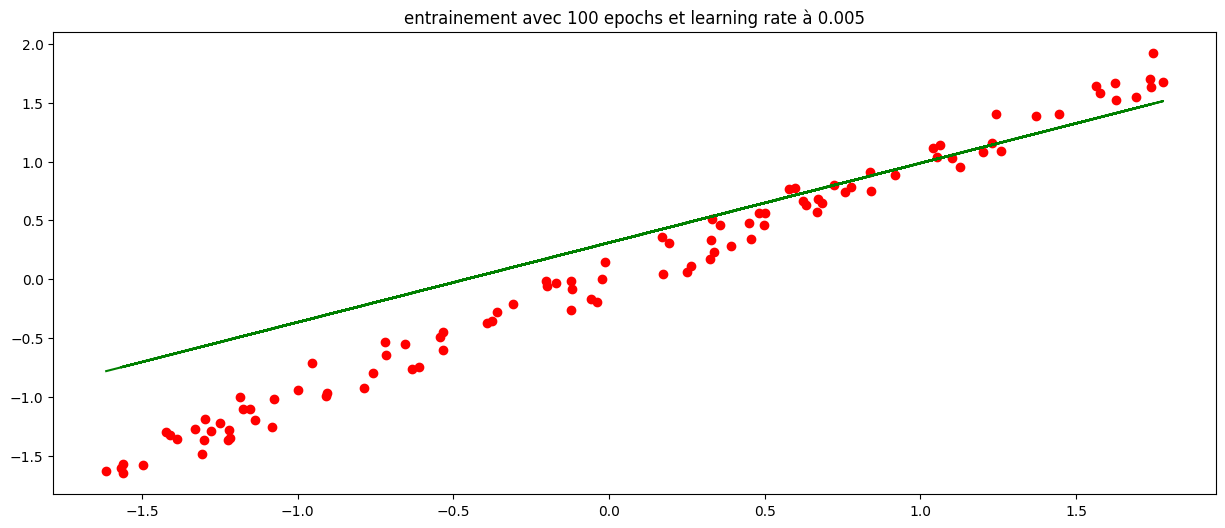

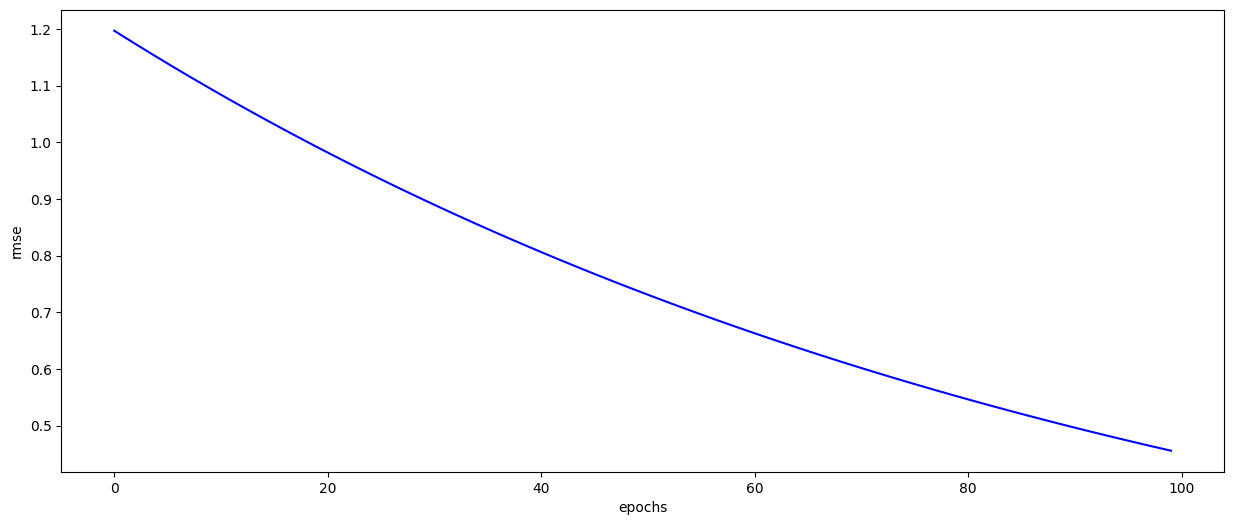

0.005 0.4557800849421881


In [ ]:
#entrainement + affichage de al droite dans le nuage de point + evolution de l'erreur
learning_rate=0.005
epoch = 100
print(f"Il s'agit du modèle entrainé sur {epoch} epochs")
a, b, rmse_values_per_epoch = gradient_descent(house_prices_df["surface"], house_prices_df["prix"], learning_rate=learning_rate, epochs=epoch)
	
plot_rmse(rmse_values_per_epoch)
print(learning_rate, rmse_values_per_epoch[-1])

In [ ]:
#Equation de droite 
def linear_regression_quadratique(a, b,c, problems):
	return a * problems**2 + b*problems + c

#affichage de la courbe dans le plan, avec problems mis dans l'ordre pour eviter les allers retour visuels
def plot(problems, solutions, predictions, epoch, learning_rate):
    plt.figure(figsize=(15, 6))

    plt.scatter(problems, solutions, color="red")

    idx = np.argsort(problems)

    plt.plot(problems[idx], predictions[idx], "g")

    plt.title(f"entrainement avec {epoch} epochs et learning rate à {learning_rate}")
    plt.show()



def plot_rmse(rmse_values_per_epoch):
	plt.figure(figsize=(15, 6))
	plt.plot(rmse_values_per_epoch, "b")
	plt.xlabel("epochs")
	plt.ylabel("rmse")
	plt.show()
	
    
#calcul itératif des dérivées partielles des variables a,b,c
def backpropagation_quadratique(a, b,c, n, problems, solutions, learning_rate, visual=False):
	dmse_da = 2/n * np.sum((a * problems**2 + b*problems + c - solutions) * problems**2)
	dmse_db = 2/n * np.sum((a * problems**2 + b*problems + c - solutions) * problems)
	dmse_dc = 2/n * np.sum(a * problems**2 + b*problems + c - solutions)

	a -= learning_rate * dmse_da
	b -= learning_rate * dmse_db
	c -= learning_rate * dmse_dc
	
	predictions = linear_regression_quadratique(a, b,c, problems)
	rmse = compute_rmse(predictions, solutions)


	if visual :
		plot(problems=problems, solutions=solutions, predictions=predictions)

	return a, b,c, rmse


def gradient_descent_quadratique(problems, solutions, learning_rate=10**(-3), epochs=100, a=None, b=None,c=None):
	a, b,c = random.random(), random.random(),random.random()

	n = len(problems)
	
	rmse_values_per_epoch_quadratique = []

	for index_epoch in range(epochs):

		a, b,c, rmse = backpropagation_quadratique(a, b,c, n, problems, solutions, learning_rate)
		rmse_values_per_epoch_quadratique.append(rmse)


	predictions = linear_regression_quadratique(a, b,c, problems)
	plot(problems=problems, solutions=solutions, predictions=predictions, epoch=epochs , learning_rate=learning_rate)

	return a, b,c, rmse_values_per_epoch_quadratique


#calcul RMSE 
def compute_rmse(predictions, solutions):
	n = len(predictions)
	return  np.sqrt(np.mean((predictions - solutions)**2))

Il s'agit du modèle entrainé sur 100 epochs


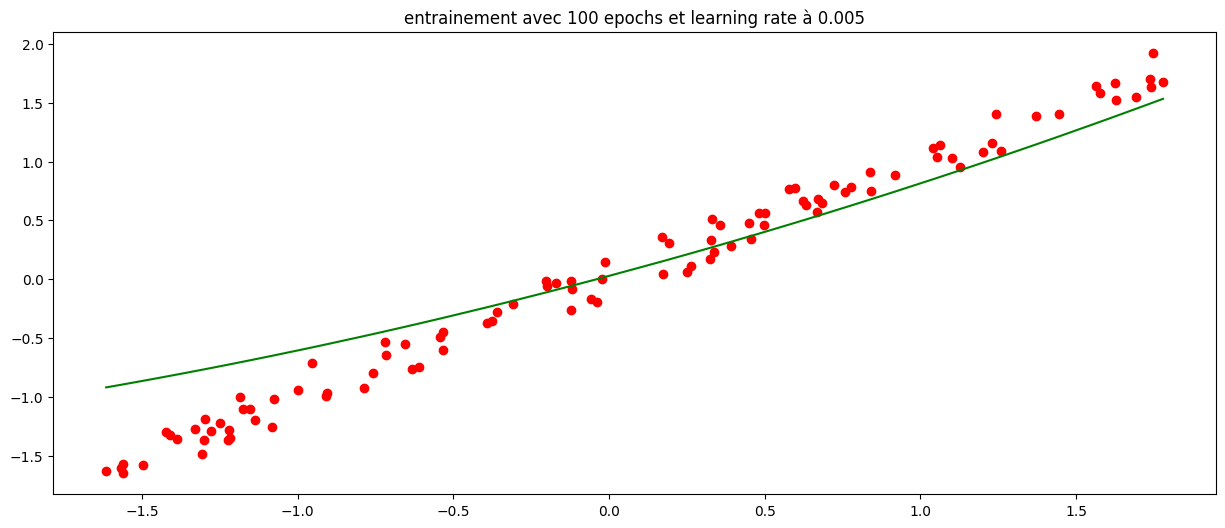

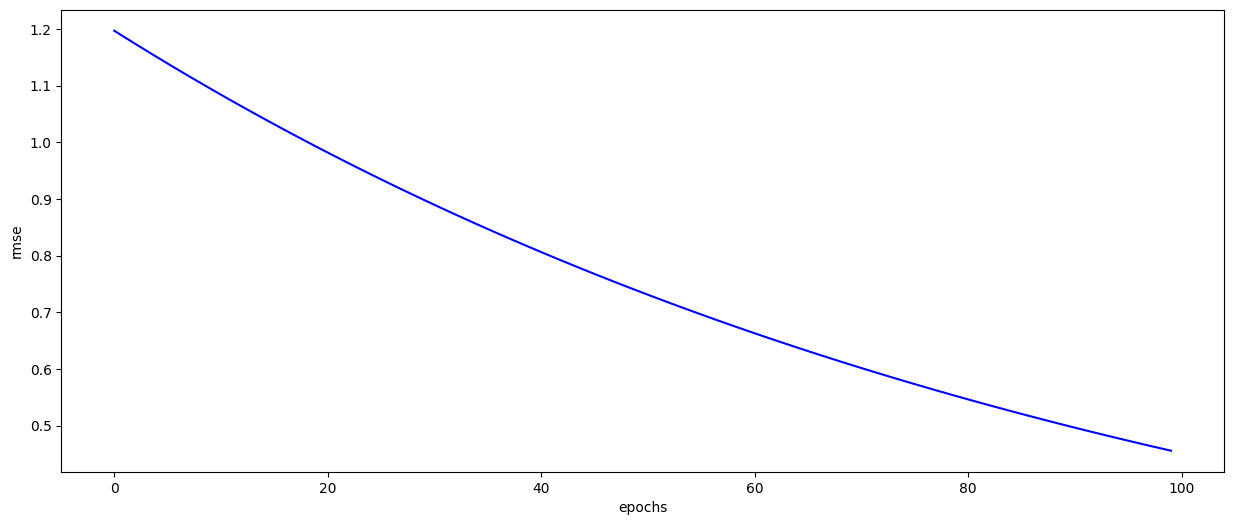

0.005 0.32525612732486514


In [ ]:
#entrainement + affichage de al droite dans le nuage de point + evolution de l'erreur
learning_rate=0.005
epoch = 100
print(f"Il s'agit du modèle entrainé sur {epoch} epochs")
a, b,c, rmse_values_per_epoch_quadratique = gradient_descent_quadratique(house_prices_df["surface"], house_prices_df["prix"], learning_rate=learning_rate, epochs=epoch)
	
plot_rmse(rmse_values_per_epoch)
print(learning_rate, rmse_values_per_epoch_quadratique[-1])

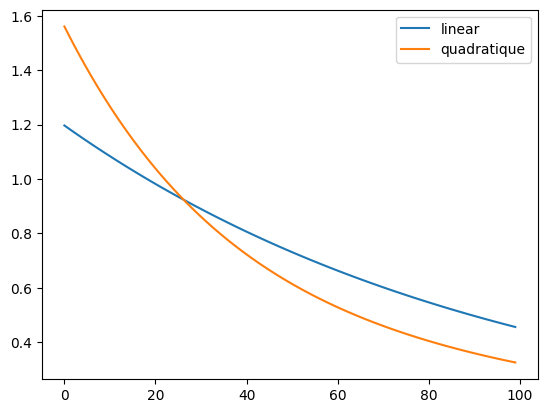

In [ ]:
#Comparaison de l'erreur entre la regression linéraire vs quadratique
plt.plot(rmse_values_per_epoch,label = "linear")
plt.plot(rmse_values_per_epoch_quadratique , label = "quadratique")
plt.legend()

6. Le modèle quadratique sera plus performant que le modèle linéaire après un certain nombre d'epochs car est par nature plus flexible et que peu de problèmes réels admettent une solution linéaire. Sachant que même dans un problème linéaire, une droite quadratique peut simplement avoir a = 0 pour devnir linéaire. On peut donc dire qu'elle sera au moins aussi performante voir plus. 